##**Business questions**
1. Which repositories are the most popular?
2. Which programming languages are most common?
3. How many repositories have more than 10000 stars?
4. Which repositories have high popularity and less opened issues?
5. Which languages have more than 5 repositories?

##**Collecting API data**

In [161]:
import pandas as pd
import requests
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"
response = requests.get(url)

In [162]:
print(response.status_code)

200


In [163]:
data = response.json()

##**Creating the dataset**

In [164]:
df = pd.DataFrame(data['items'])
df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76115,2947,197375,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34334,2409,164374,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,22045,13,89715,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15274,52,82621,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15621,26,74132,master,1.0


In [165]:
df.columns

Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

In [166]:
df.dtypes

,0
id,int64
node_id,object
name,object
full_name,object
private,bool
...,...
forks,int64
open_issues,int64
watchers,int64
default_branch,object


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

##**Selecting required columns**

In [168]:
df = df[['name', 'owner', 'language', 'stargazers_count', 'forks_count', "watchers_count", "open_issues_count", "created_at", "updated_at", 'license']]

##**Extracting required values**

In [169]:
df['owner_login'] = df['owner'].apply(lambda x: x['login'])
df['license_name'] = df['license'].apply(lambda x: x['name'] if x else None)
df = df.drop(columns = ['owner', 'license'])

In [170]:
df.head()

,name,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,owner_login,license_name
0,tensorflow,C++,197375,76115,197375,2947,2015-11-07T01:19:20Z,2026-08-23T21:07:14Z,tensorflow,Apache License 2.0
1,transformers,Python,164374,34334,164374,2409,2018-10-29T13:56:00Z,2026-08-23T22:28:42Z,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89715,22045,89715,13,2021-03-03T01:34:05Z,2026-08-23T22:30:54Z,microsoft,MIT License
3,funNLP,Python,82621,15274,82621,52,2018-08-21T11:20:39Z,2026-08-23T20:09:35Z,fighting41love,None
4,awesome-machine-learning,Python,74132,15621,74132,26,2014-07-15T19:11:19Z,2026-08-23T21:58:31Z,josephmisiti,Other


##**Handling missing values**

In [171]:
df.isna().sum()

,0
name,0
language,23
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
owner_login,0
license_name,22


In [172]:
df = df.fillna('Unknown')
df.isna().sum()

,0
name,0
language,0
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
owner_login,0
license_name,0


In [173]:
df.head()

,name,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,owner_login,license_name
0,tensorflow,C++,197375,76115,197375,2947,2015-11-07T01:19:20Z,2026-08-23T21:07:14Z,tensorflow,Apache License 2.0
1,transformers,Python,164374,34334,164374,2409,2018-10-29T13:56:00Z,2026-08-23T22:28:42Z,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89715,22045,89715,13,2021-03-03T01:34:05Z,2026-08-23T22:30:54Z,microsoft,MIT License
3,funNLP,Python,82621,15274,82621,52,2018-08-21T11:20:39Z,2026-08-23T20:09:35Z,fighting41love,Unknown
4,awesome-machine-learning,Python,74132,15621,74132,26,2014-07-15T19:11:19Z,2026-08-23T21:58:31Z,josephmisiti,Other


##**Handling duplicated records**

In [174]:
df.duplicated().sum()

np.int64(0)

##**Preparing the dataset**

In [175]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['updated_at'] = pd.to_datetime(df['updated_at'])
df.dtypes

,0
name,object
language,object
stargazers_count,int64
forks_count,int64
watchers_count,int64
open_issues_count,int64
created_at,"datetime64[ns, UTC]"
updated_at,"datetime64[ns, UTC]"
owner_login,object
license_name,object


In [176]:
df = df.rename(columns= {'stargazers_count' : 'stars', 'forks_count' : 'forks', 'watchers_count' : 'watchers', 'open_issues_count' : 'open_issues', 'created_at' : 'created_date', 'updated_at': 'updated_date'})

In [177]:
df.head()

,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,tensorflow,Apache License 2.0
1,transformers,Python,164374,34334,164374,2409,2018-10-29 13:56:00+00:00,2026-08-23 22:28:42+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89715,22045,89715,13,2021-03-03 01:34:05+00:00,2026-08-23 22:30:54+00:00,microsoft,MIT License
3,funNLP,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,fighting41love,Unknown
4,awesome-machine-learning,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 21:58:31+00:00,josephmisiti,Other


##**Saving and verifying the dataset**

In [178]:
df.to_csv('github_projects.csv')
check = pd.read_csv('github_projects.csv')
check.head()

,Unnamed: 0,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,0,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,tensorflow,Apache License 2.0
1,1,transformers,Python,164374,34334,164374,2409,2018-10-29 13:56:00+00:00,2026-08-23 22:28:42+00:00,huggingface,Apache License 2.0
2,2,ML-For-Beginners,Jupyter Notebook,89715,22045,89715,13,2021-03-03 01:34:05+00:00,2026-08-23 22:30:54+00:00,microsoft,MIT License
3,3,funNLP,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,fighting41love,Unknown
4,4,awesome-machine-learning,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 21:58:31+00:00,josephmisiti,Other


In [179]:
check.columns

Index(['Unnamed: 0', 'name', 'language', 'stars', 'forks', 'watchers',
       'open_issues', 'created_date', 'updated_date', 'owner_login',
       'license_name'],
      dtype='object')

In [180]:
df.dtypes

,0
name,object
language,object
stars,int64
forks,int64
watchers,int64
open_issues,int64
created_date,"datetime64[ns, UTC]"
updated_date,"datetime64[ns, UTC]"
owner_login,object
license_name,object


In [181]:
df.shape

(100, 10)

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   name          100 non-null    object             
 1   language      100 non-null    object             
 2   stars         100 non-null    int64              
 3   forks         100 non-null    int64              
 4   watchers      100 non-null    int64              
 5   open_issues   100 non-null    int64              
 6   created_date  100 non-null    datetime64[ns, UTC]
 7   updated_date  100 non-null    datetime64[ns, UTC]
 8   owner_login   100 non-null    object             
 9   license_name  100 non-null    object             
dtypes: datetime64[ns, UTC](2), int64(4), object(4)
memory usage: 7.9+ KB


##**Creating the SQLite database**

In [183]:
import sqlite3

!pip install ipython-sql==0.5.0 prettytable==3.9.0

%load_ext sql

%config SqlMagic.style = 'PLAIN_COLUMNS'

%sql sqlite:///repositories.db

repositories_df = pd.read_csv('github_projects.csv')

repositories_df.to_sql('repositories', "sqlite:///repositories.db", if_exists="replace", index=False)

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


100

##**Filtiering and searching queries**

In [184]:
%%sql
SELECT * FROM repositories
WHERE stars > 10000;

 * sqlite:///repositories.db
Done.


Unnamed: 0,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,tensorflow,Apache License 2.0
1,transformers,Python,164374,34334,164374,2409,2018-10-29 13:56:00+00:00,2026-08-23 22:28:42+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89715,22045,89715,13,2021-03-03 01:34:05+00:00,2026-08-23 22:30:54+00:00,microsoft,MIT License
3,funNLP,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,fighting41love,Unknown
4,awesome-machine-learning,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 21:58:31+00:00,josephmisiti,Other
5,scikit-learn,Python,67035,27305,67035,2127,2010-08-17 09:43:38+00:00,2026-08-23 21:47:41+00:00,scikit-learn,"BSD 3-Clause ""New"" or ""Revised"" License"
6,gradio,Python,43409,3579,43409,170,2018-12-19 08:24:04+00:00,2026-08-23 19:53:10+00:00,gradio-app,Apache License 2.0
7,500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,Unknown,36474,7461,36474,68,2021-01-02 12:08:37+00:00,2026-08-23 22:32:54+00:00,ashishpatel26,Unknown
8,C-Plus-Plus,C++,34599,7852,34599,29,2016-07-16 10:19:45+00:00,2026-08-23 19:11:50+00:00,TheAlgorithms,MIT License
9,netron,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 22:17:43+00:00,lutzroeder,MIT License


In [185]:
%%sql
SELECT * FROM repositories
WHERE name LIKE '%Machine%';

 * sqlite:///repositories.db
Done.


Unnamed: 0,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
4,awesome-machine-learning,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 21:58:31+00:00,josephmisiti,Other
7,500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,Unknown,36474,7461,36474,68,2021-01-02 12:08:37+00:00,2026-08-23 22:32:54+00:00,ashishpatel26,Unknown
12,machine-learning-for-software-engineers,Unknown,28869,6147,28869,32,2016-10-09 21:20:25+00:00,2026-08-23 19:47:14+00:00,ZuzooVn,Creative Commons Attribution Share Alike 4.0 International
16,homemade-machine-learning,Jupyter Notebook,24774,4194,24774,30,2018-11-01 04:34:19+00:00,2026-08-23 16:53:03+00:00,trekhleb,MIT License
23,awesome-production-machine-learning,Unknown,20865,2590,20865,31,2018-08-15 14:28:41+00:00,2026-08-23 20:12:49+00:00,EthicalML,MIT License
24,machine-learning-for-trading,Jupyter Notebook,20593,5552,20593,3,2018-05-09 12:33:08+00:00,2026-08-23 20:49:13+00:00,stefan-jansen,MIT License
25,stanford-cs-229-machine-learning,Unknown,20147,4252,20147,20,2018-08-04 23:01:00+00:00,2026-08-23 17:52:25+00:00,afshinea,MIT License
29,Machine-Learning-Tutorials,Unknown,18140,3969,18140,47,2015-09-12 14:51:38+00:00,2026-08-23 13:27:46+00:00,ujjwalkarn,Creative Commons Zero v1.0 Universal
47,machine-learning-zoomcamp,Jupyter Notebook,13999,3103,13999,3,2020-04-17 04:29:23+00:00,2026-08-23 22:28:01+00:00,DataTalksClub,Unknown
52,machine-learning-interview,Unknown,12790,2045,12790,9,2020-08-11 06:26:32+00:00,2026-08-23 18:35:35+00:00,khangich,Unknown


##**Using logical operators**

In [186]:
%%sql
SELECT * FROM repositories
WHERE language = 'Python' OR stars > 20000;

 * sqlite:///repositories.db
Done.


Unnamed: 0,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,tensorflow,Apache License 2.0
1,transformers,Python,164374,34334,164374,2409,2018-10-29 13:56:00+00:00,2026-08-23 22:28:42+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89715,22045,89715,13,2021-03-03 01:34:05+00:00,2026-08-23 22:30:54+00:00,microsoft,MIT License
3,funNLP,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,fighting41love,Unknown
4,awesome-machine-learning,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 21:58:31+00:00,josephmisiti,Other
5,scikit-learn,Python,67035,27305,67035,2127,2010-08-17 09:43:38+00:00,2026-08-23 21:47:41+00:00,scikit-learn,"BSD 3-Clause ""New"" or ""Revised"" License"
6,gradio,Python,43409,3579,43409,170,2018-12-19 08:24:04+00:00,2026-08-23 19:53:10+00:00,gradio-app,Apache License 2.0
7,500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,Unknown,36474,7461,36474,68,2021-01-02 12:08:37+00:00,2026-08-23 22:32:54+00:00,ashishpatel26,Unknown
8,C-Plus-Plus,C++,34599,7852,34599,29,2016-07-16 10:19:45+00:00,2026-08-23 19:11:50+00:00,TheAlgorithms,MIT License
9,netron,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 22:17:43+00:00,lutzroeder,MIT License


In [187]:
%%sql
SELECT * FROM repositories
WHERE stars > 30000 AND open_issues < 25;

 * sqlite:///repositories.db
Done.


Unnamed: 0,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
2,ML-For-Beginners,Jupyter Notebook,89715,22045,89715,13,2021-03-03 01:34:05+00:00,2026-08-23 22:30:54+00:00,microsoft,MIT License
9,netron,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 22:17:43+00:00,lutzroeder,MIT License
11,applied-ml,Unknown,30076,3992,30076,8,2020-07-04 18:57:47+00:00,2026-08-23 22:32:44+00:00,eugeneyan,MIT License


In [188]:
%%sql
SELECT * FROM repositories
WHERE language NOT IN ('Jupyter Notebook', 'Python', 'C++', 'Unknown');

 * sqlite:///repositories.db
Done.


Unnamed: 0,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
9,netron,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 22:17:43+00:00,lutzroeder,MIT License
19,C,C,22338,4770,22338,18,2016-07-16 10:17:03+00:00,2026-08-23 17:06:23+00:00,TheAlgorithms,GNU General Public License v3.0
26,ml-agents,C#,19643,4485,19643,20,2017-09-08 21:09:04+00:00,2026-08-23 11:31:41+00:00,Unity-Technologies,Other
34,transformers.js,JavaScript,16264,1183,16264,279,2023-02-13 13:51:45+00:00,2026-08-23 07:40:10+00:00,huggingface,Apache License 2.0
45,mit-deep-learning-book-pdf,Java,14209,2910,14209,12,2017-04-07 10:46:50+00:00,2026-08-23 16:06:43+00:00,janishar,Unknown
51,deep-learning-drizzle,HTML,12933,2989,12933,5,2018-11-26 01:17:36+00:00,2026-08-23 20:08:19+00:00,kmario23,Unknown
54,predictionio,Scala,12518,1897,12518,80,2013-01-25 19:42:32+00:00,2026-08-21 05:59:51+00:00,apache,Apache License 2.0
55,lime,JavaScript,12166,1847,12166,133,2016-03-15 22:18:10+00:00,2026-08-22 17:53:50+00:00,marcotcr,"BSD 2-Clause ""Simplified"" License"
65,machine-learning-systems-design,HTML,10541,1632,10541,11,2019-11-24 23:16:28+00:00,2026-08-23 14:23:44+00:00,chiphuyen,Unknown
72,cog,Go,9460,696,9460,70,2021-02-26 23:43:09+00:00,2026-08-22 06:21:40+00:00,replicate,Apache License 2.0


##**Sorting and limiting queries**

In [189]:
%%sql
SELECT * FROM repositories
ORDER BY stars DESC;

 * sqlite:///repositories.db
Done.


Unnamed: 0,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,tensorflow,Apache License 2.0
1,transformers,Python,164374,34334,164374,2409,2018-10-29 13:56:00+00:00,2026-08-23 22:28:42+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89715,22045,89715,13,2021-03-03 01:34:05+00:00,2026-08-23 22:30:54+00:00,microsoft,MIT License
3,funNLP,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,fighting41love,Unknown
4,awesome-machine-learning,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 21:58:31+00:00,josephmisiti,Other
5,scikit-learn,Python,67035,27305,67035,2127,2010-08-17 09:43:38+00:00,2026-08-23 21:47:41+00:00,scikit-learn,"BSD 3-Clause ""New"" or ""Revised"" License"
6,gradio,Python,43409,3579,43409,170,2018-12-19 08:24:04+00:00,2026-08-23 19:53:10+00:00,gradio-app,Apache License 2.0
7,500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,Unknown,36474,7461,36474,68,2021-01-02 12:08:37+00:00,2026-08-23 22:32:54+00:00,ashishpatel26,Unknown
8,C-Plus-Plus,C++,34599,7852,34599,29,2016-07-16 10:19:45+00:00,2026-08-23 19:11:50+00:00,TheAlgorithms,MIT License
9,netron,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 22:17:43+00:00,lutzroeder,MIT License


In [190]:
%%sql
SELECT * FROM repositories
ORDER BY stars DESC
LIMIT 10;

 * sqlite:///repositories.db
Done.


Unnamed: 0,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,tensorflow,Apache License 2.0
1,transformers,Python,164374,34334,164374,2409,2018-10-29 13:56:00+00:00,2026-08-23 22:28:42+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89715,22045,89715,13,2021-03-03 01:34:05+00:00,2026-08-23 22:30:54+00:00,microsoft,MIT License
3,funNLP,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,fighting41love,Unknown
4,awesome-machine-learning,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 21:58:31+00:00,josephmisiti,Other
5,scikit-learn,Python,67035,27305,67035,2127,2010-08-17 09:43:38+00:00,2026-08-23 21:47:41+00:00,scikit-learn,"BSD 3-Clause ""New"" or ""Revised"" License"
6,gradio,Python,43409,3579,43409,170,2018-12-19 08:24:04+00:00,2026-08-23 19:53:10+00:00,gradio-app,Apache License 2.0
7,500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,Unknown,36474,7461,36474,68,2021-01-02 12:08:37+00:00,2026-08-23 22:32:54+00:00,ashishpatel26,Unknown
8,C-Plus-Plus,C++,34599,7852,34599,29,2016-07-16 10:19:45+00:00,2026-08-23 19:11:50+00:00,TheAlgorithms,MIT License
9,netron,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 22:17:43+00:00,lutzroeder,MIT License


##**Using aggregate functions**

In [191]:
%%sql
SELECT COUNT(*) AS TotalRepositories
FROM repositories;

 * sqlite:///repositories.db
Done.


TotalRepositories
100


In [192]:
%%sql
SELECT AVG(stars) AS AverageStars
FROM repositories;

 * sqlite:///repositories.db
Done.


AverageStars
20825.74


##**Grouping analysis**

In [193]:
%%sql
SELECT * , language
FROM repositories
GROUP BY language;

 * sqlite:///repositories.db
Done.


Unnamed: 0,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name,language_1
19,C,C,22338,4770,22338,18,2016-07-16 10:17:03+00:00,2026-08-23 17:06:23+00:00,TheAlgorithms,GNU General Public License v3.0,C
26,ml-agents,C#,19643,4485,19643,20,2017-09-08 21:09:04+00:00,2026-08-23 11:31:41+00:00,Unity-Technologies,Other,C#
0,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,tensorflow,Apache License 2.0,C++
93,machine-learning-yearning-cn,CSS,7845,1499,7845,4,2018-06-19 19:26:39+00:00,2026-08-23 08:15:51+00:00,deeplearning-ai,Other,CSS
72,cog,Go,9460,696,9460,70,2021-02-26 23:43:09+00:00,2026-08-22 06:21:40+00:00,replicate,Apache License 2.0,Go
51,deep-learning-drizzle,HTML,12933,2989,12933,5,2018-11-26 01:17:36+00:00,2026-08-23 20:08:19+00:00,kmario23,Unknown,HTML
45,mit-deep-learning-book-pdf,Java,14209,2910,14209,12,2017-04-07 10:46:50+00:00,2026-08-23 16:06:43+00:00,janishar,Unknown,Java
9,netron,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 22:17:43+00:00,lutzroeder,MIT License,JavaScript
2,ML-For-Beginners,Jupyter Notebook,89715,22045,89715,13,2021-03-03 01:34:05+00:00,2026-08-23 22:30:54+00:00,microsoft,MIT License,Jupyter Notebook
96,awesome-youtubers,Markdown,7745,498,7745,2,2020-08-25 14:18:15+00:00,2026-08-23 14:25:22+00:00,JoseDeFreitas,Creative Commons Zero v1.0 Universal,Markdown


In [194]:
%%sql
SELECT language, COUNT(*) AS RepositoryCount
FROM repositories
GROUP BY language
HAVING RepositoryCount > 5;

 * sqlite:///repositories.db
Done.


language,RepositoryCount
C++,12
Jupyter Notebook,19
Python,30
Unknown,23


##**Creating pythog visualizations**

In [195]:
import matplotlib.pyplot as plt

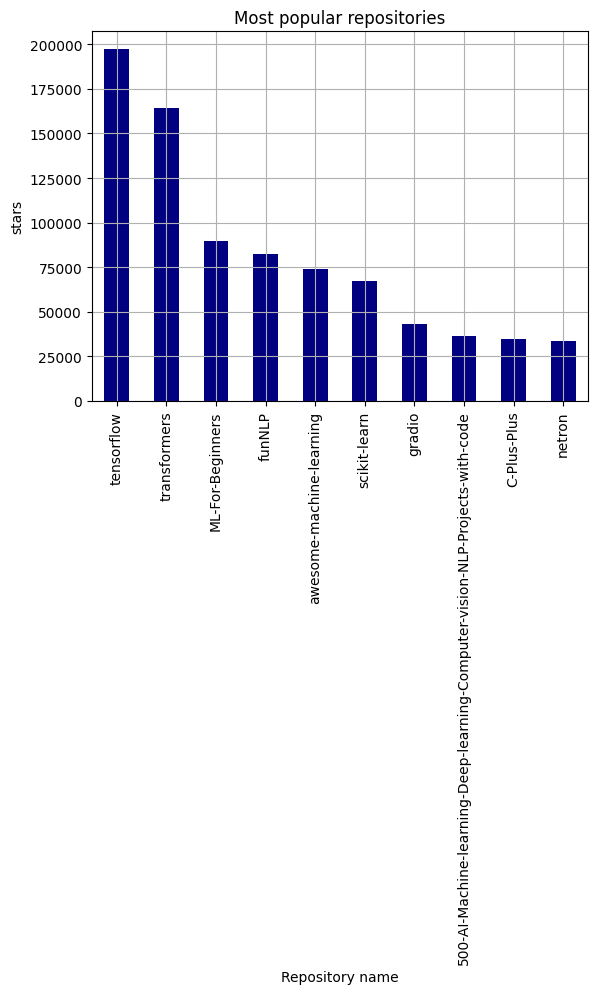

In [196]:
df.groupby('name')['stars'].sum().sort_values(ascending=False).head(10).plot(kind='bar', color='navy')
plt.xlabel('Repository name')
plt.ylabel('stars')
plt.title('Most popular repositories')
plt.grid()
plt.show()

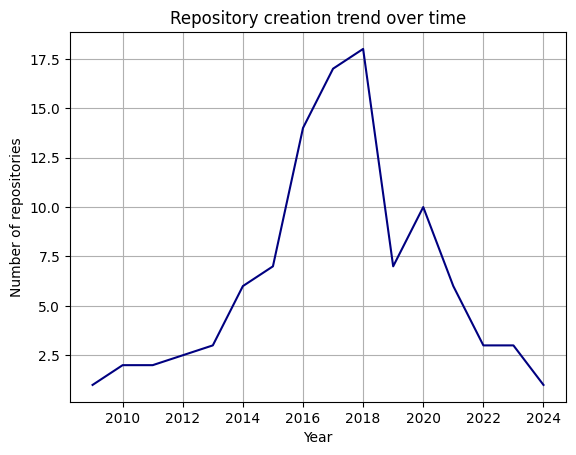

In [197]:
df.groupby(df['created_date'].dt.year)['name'].count().plot(kind='line', color='navy')
plt.xlabel('Year')
plt.ylabel('Number of repositories')
plt.title('Repository creation trend over time')
plt.grid()
plt.show()

##**Interpreting results**

***Improtant patterns:***
* Repositories with highest stars are most popular repositories.
* Not all highly starred repositories are equally active, a repository can have many stars while having relatively few open issues or recent updates.
* Some repositories have fewer than 25 open issues despite having high popularity.

***Trends in the data:***
* Highest number of repositories was created at 2016/2017/2018.
* The increasing number of forks over time can indicate growing community participation and reuse of projects.

***Answers of business questions:***
1. Most popular repositories are Tenserflow, transformer and ML-For-Begginers.
2. Python and Jupyter Notebook are the most used languages among the repositories.
3. There are 69 repositories which have more than 10000 stars.
4. Top 3 repositories which have high popularity and less issues are ML-For-Begginers, netron and applied-ml.
5. C++, Jupyter, Notebook python are repositories which have more than 5 repositories.